In [1]:
!pip install yfinance hmmlearn cvxpy pandas numpy matplotlib scikit-learn

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

import cvxpy as cp

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
nifty = yf.download("^NSEI", start="2015-01-01", end="2025-01-01")

nifty.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800


In [4]:
gold = yf.download("GOLDBEES.NS", start="2015-01-01", end="2025-01-01")
bond = yf.download("SETFNIFBK.NS", start="2015-01-01", end="2025-01-01")
vix = yf.download("^INDIAVIX", start="2015-01-01", end="2025-01-01")

print("Downloaded Successfully!")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Downloaded Successfully!


In [7]:
type(nifty["Close"])

pandas.core.frame.DataFrame

In [8]:
type(gold["Close"])

pandas.core.frame.DataFrame

In [9]:
type(bond["Close"])

pandas.core.frame.DataFrame

In [10]:
type(vix["Close"])

pandas.core.frame.DataFrame

In [11]:
prices = pd.concat(
    [
        nifty["Close"].iloc[:, 0],
        gold["Close"].iloc[:, 0],
        bond["Close"].iloc[:, 0],
        vix["Close"].iloc[:, 0]
    ],
    axis=1
)

prices.columns = ["NIFTY", "GOLD", "BOND", "VIX"]

prices = prices.ffill().dropna()

prices.head()

,NIFTY,GOLD,BOND,VIX
Date,,,,
2015-03-25,8530.799805,24.024500,180.466110,13.14
2015-03-26,8342.150391,24.550501,181.102737,15.16
2015-03-27,8341.400391,24.195000,174.839096,14.50
2015-03-30,8492.299805,24.111000,178.784683,14.26
2015-03-31,8491.000000,23.989500,180.510880,14.49


In [13]:
print(type(nifty))
print(type(nifty["Close"]))
print(nifty.columns)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
MultiIndex([( 'Close', '^NSEI'),
            (  'High', '^NSEI'),
            (   'Low', '^NSEI'),
            (  'Open', '^NSEI'),
            ('Volume', '^NSEI')],
           names=['Price', 'Ticker'])


In [14]:
nifty["Close"].squeeze()

,^NSEI
Date,
2015-01-02,8395.450195
2015-01-05,8378.400391
2015-01-06,8127.350098
2015-01-07,8102.100098
2015-01-08,8234.599609
...,...
2024-12-24,23727.650391
2024-12-26,23750.199219
2024-12-27,23813.400391


In [15]:
prices = pd.concat([
    nifty["Close"].squeeze(),
    gold["Close"].squeeze(),
    bond["Close"].squeeze(),
    vix["Close"].squeeze()
], axis=1)

prices.columns = ["NIFTY", "GOLD", "BOND", "VIX"]

prices = prices.ffill().dropna()

prices.head()

,NIFTY,GOLD,BOND,VIX
Date,,,,
2015-03-25,8530.799805,24.024500,180.466110,13.14
2015-03-26,8342.150391,24.550501,181.102737,15.16
2015-03-27,8341.400391,24.195000,174.839096,14.50
2015-03-30,8492.299805,24.111000,178.784683,14.26
2015-03-31,8491.000000,23.989500,180.510880,14.49


In [16]:
returns = prices.pct_change().dropna()

returns.head()

,NIFTY,GOLD,BOND,VIX
Date,,,,
2015-03-26,-0.022114,0.021894,0.003528,0.153729
2015-03-27,-0.000090,-0.014480,-0.034586,-0.043536
2015-03-30,0.018090,-0.003472,0.022567,-0.016552
2015-03-31,-0.000153,-0.005039,0.009655,0.016129
2015-04-01,0.011218,0.006107,0.016451,-0.056591


In [17]:
features = pd.DataFrame(index=returns.index)

# Daily return
features["Return"] = returns["NIFTY"]

# 5-day momentum
features["Momentum_5"] = prices["NIFTY"].pct_change(5)

# 20-day momentum
features["Momentum_20"] = prices["NIFTY"].pct_change(20)

# 20-day rolling volatility
features["Volatility"] = returns["NIFTY"].rolling(20).std()

# India VIX
features["VIX"] = prices["VIX"]

features = features.dropna()

features.head()

,Return,Momentum_5,Momentum_20,Volatility,VIX
Date,,,,,
2015-04-27,-0.011011,-0.027734,-0.037159,0.010568,18.740000
2015-04-28,0.008741,-0.010999,-0.006779,0.009666,17.410000
2015-04-29,-0.005534,-0.022533,-0.012186,0.009737,17.240000
2015-04-30,-0.007069,-0.025815,-0.036598,0.008777,17.230000
2015-05-04,0.018389,0.003215,-0.018732,0.009874,17.309999


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(features)

print(X.shape)

(2391, 5)


In [19]:
from hmmlearn.hmm import GaussianHMM

model = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model.fit(X)

states = model.predict(X)

features["State"] = states

features.head()

,Return,Momentum_5,Momentum_20,Volatility,VIX,State
Date,,,,,,
2015-04-27,-0.011011,-0.027734,-0.037159,0.010568,18.740000,0
2015-04-28,0.008741,-0.010999,-0.006779,0.009666,17.410000,0
2015-04-29,-0.005534,-0.022533,-0.012186,0.009737,17.240000,0
2015-04-30,-0.007069,-0.025815,-0.036598,0.008777,17.230000,0
2015-05-04,0.018389,0.003215,-0.018732,0.009874,17.309999,0


In [20]:
features["State"].value_counts()

,count
State,
0,1242
1,905
2,244


In [21]:
state_summary = features.groupby("State").agg({
    "Return": "mean",
    "Volatility": "mean",
    "VIX": "mean"
})

print(state_summary)

         Return  Volatility        VIX
State                                 
0      0.000179    0.009338  17.699018
1      0.000788    0.005869  12.916475
2      0.000995    0.019073  28.470164


In [22]:
regime_map = {
    0: "Bear",
    1: "Bull",
    2: "Crisis"
}

features["Regime"] = features["State"].map(regime_map)

features.head()

,Return,Momentum_5,Momentum_20,Volatility,VIX,State,Regime
Date,,,,,,,
2015-04-27,-0.011011,-0.027734,-0.037159,0.010568,18.740000,0,Bear
2015-04-28,0.008741,-0.010999,-0.006779,0.009666,17.410000,0,Bear
2015-04-29,-0.005534,-0.022533,-0.012186,0.009737,17.240000,0,Bear
2015-04-30,-0.007069,-0.025815,-0.036598,0.008777,17.230000,0,Bear
2015-05-04,0.018389,0.003215,-0.018732,0.009874,17.309999,0,Bear


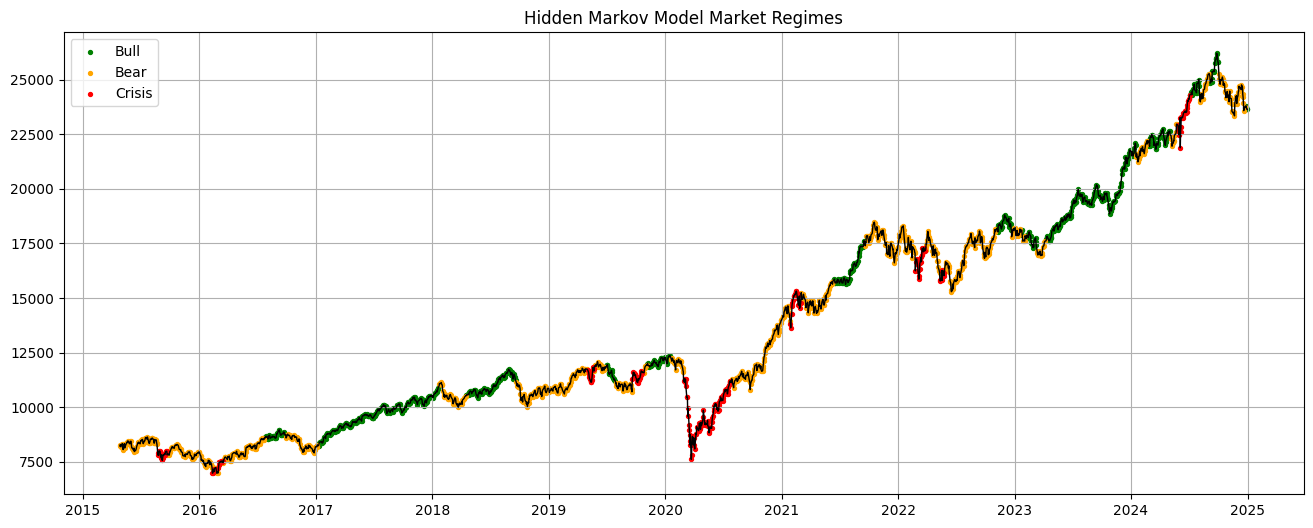

In [23]:
plt.figure(figsize=(16,6))

plt.plot(prices.loc[features.index]["NIFTY"],
         color="black",
         linewidth=1)

colors = {
    "Bull":"green",
    "Bear":"orange",
    "Crisis":"red"
}

for regime, color in colors.items():

    mask = features["Regime"] == regime

    plt.scatter(
        features.index[mask],
        prices.loc[features.index]["NIFTY"][mask],
        color=color,
        s=8,
        label=regime
    )

plt.legend()

plt.title("Hidden Markov Model Market Regimes")

plt.grid(True)

plt.show()

In [24]:
transition = pd.DataFrame(
    model.transmat_,
    columns=["To 0","To 1","To 2"],
    index=["From 0","From 1","From 2"]
)

transition

,To 0,To 1,To 2
From 0,0.980282,0.011433,8.285620e-03
From 1,0.015737,0.984263,6.221805e-76
From 2,0.037386,0.003566,9.590478e-01


In [25]:
train_size = 750
step_size = 30

walk_results = []

for start in range(0, len(features) - train_size - step_size, step_size):

    train = features.iloc[start:start + train_size]
    test = features.iloc[start + train_size:start + train_size + step_size]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        train[["Return", "Momentum_5", "Momentum_20", "Volatility", "VIX"]]
    )

    X_test = scaler.transform(
        test[["Return", "Momentum_5", "Momentum_20", "Volatility", "VIX"]]
    )

    hmm = GaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=1000,
        random_state=42
    )

    hmm.fit(X_train)

    test = test.copy()
    test["State"] = hmm.predict(X_test)

    walk_results.append(test)

walk_results = pd.concat(walk_results)

walk_results.head()

,Return,Momentum_5,Momentum_20,Volatility,VIX,State,Regime
Date,,,,,,,
2018-05-09,0.002230,0.002207,0.032632,0.003763,14.27,2,Bull
2018-05-10,-0.002341,0.003455,0.028741,0.003866,14.43,1,Bull
2018-05-11,0.008394,0.017729,0.033260,0.004136,13.98,1,Bull
2018-05-14,0.000009,0.008502,0.031105,0.004150,14.25,1,Bull
2018-05-15,-0.000440,0.007842,0.025977,0.004110,13.17,1,Bull


In [26]:
regime_map = {
    0: "Bear",
    1: "Bull",
    2: "Crisis"
}

walk_results["Regime"] = walk_results["State"].map(regime_map)

walk_results.head()

,Return,Momentum_5,Momentum_20,Volatility,VIX,State,Regime
Date,,,,,,,
2018-05-09,0.002230,0.002207,0.032632,0.003763,14.27,2,Crisis
2018-05-10,-0.002341,0.003455,0.028741,0.003866,14.43,1,Bull
2018-05-11,0.008394,0.017729,0.033260,0.004136,13.98,1,Bull
2018-05-14,0.000009,0.008502,0.031105,0.004150,14.25,1,Bull
2018-05-15,-0.000440,0.007842,0.025977,0.004110,13.17,1,Bull


In [27]:
weights = {
    "Bull": np.array([0.70, 0.20, 0.10]),
    "Bear": np.array([0.40, 0.30, 0.30]),
    "Crisis": np.array([0.20, 0.40, 0.40])
}

In [28]:
returns_subset = returns.loc[walk_results.index]

portfolio_returns = []

for i in range(len(walk_results)):

    regime = walk_results["Regime"].iloc[i]

    w = weights[regime]

    r = returns_subset.iloc[i][["NIFTY","GOLD","BOND"]].values

    portfolio_returns.append(np.dot(w, r))

portfolio_returns = pd.Series(
    portfolio_returns,
    index=walk_results.index
)

portfolio_returns.head()

,0
Date,
2018-05-09,0.004239
2018-05-10,0.000258
2018-05-11,0.006779
2018-05-14,0.000273
2018-05-15,-0.000565


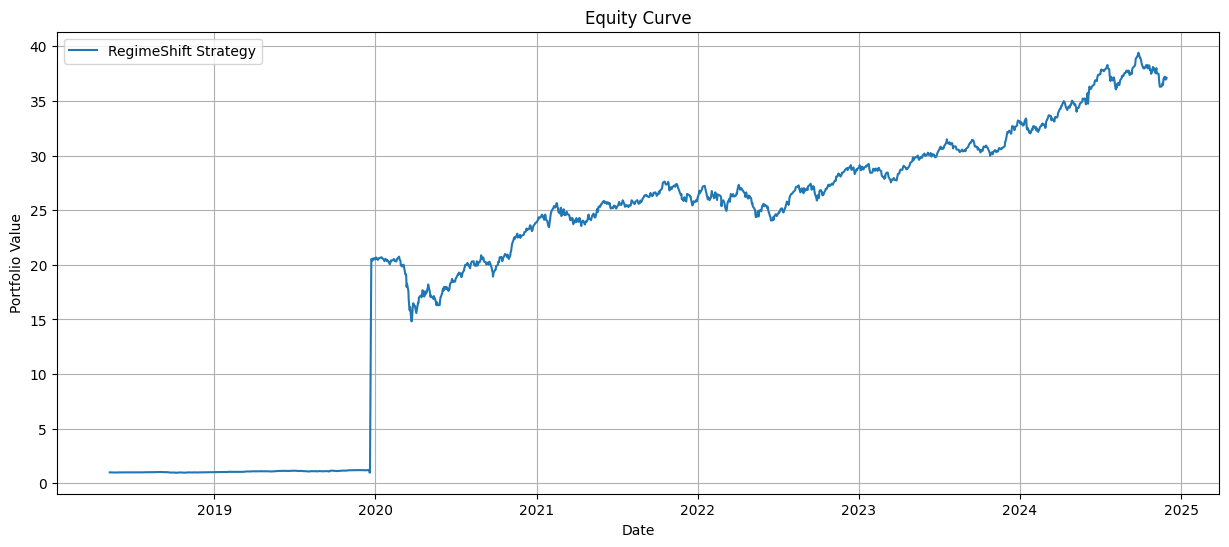

In [29]:
equity_curve = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(15,6))

plt.plot(equity_curve, label="RegimeShift Strategy")

plt.title("Equity Curve")

plt.xlabel("Date")

plt.ylabel("Portfolio Value")

plt.grid(True)

plt.legend()

plt.show()

In [30]:
def sharpe_ratio(r):
    return np.sqrt(252) * r.mean() / r.std()

print("Sharpe Ratio :", sharpe_ratio(portfolio_returns))

Sharpe Ratio : 0.4074699929409334


In [31]:
equal_weights = np.array([1/3, 1/3, 1/3])

equal_returns = returns_subset[["NIFTY","GOLD","BOND"]].dot(equal_weights)

benchmark_weights = np.array([0.60, 0.00, 0.40])

benchmark_returns = returns_subset[["NIFTY","GOLD","BOND"]].dot(benchmark_weights)

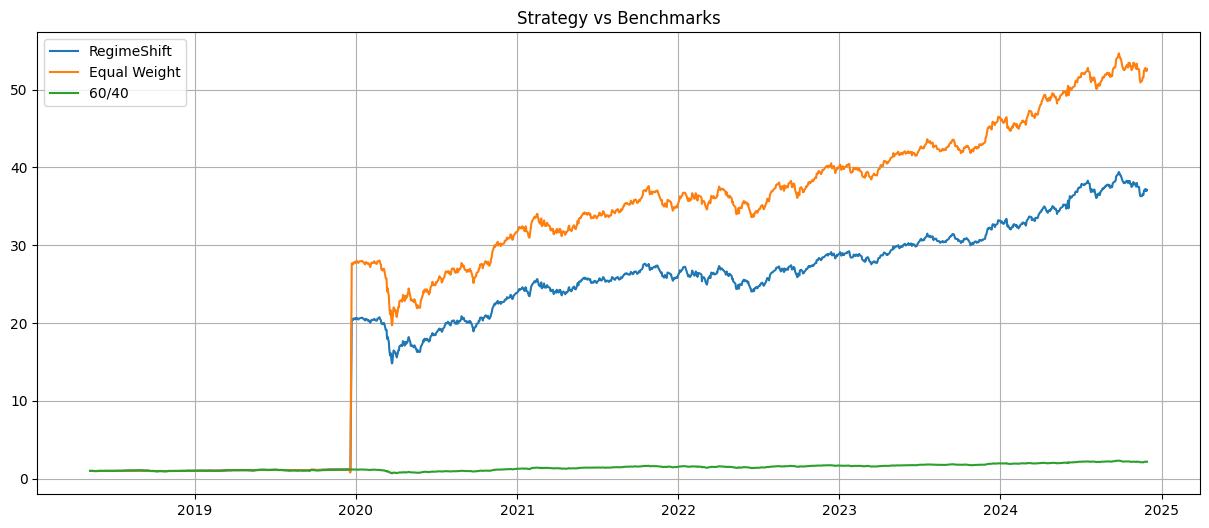

In [32]:
strategy = (1 + portfolio_returns).cumprod()
equal = (1 + equal_returns).cumprod()
benchmark = (1 + benchmark_returns).cumprod()

plt.figure(figsize=(15,6))

plt.plot(strategy,label="RegimeShift")
plt.plot(equal,label="Equal Weight")
plt.plot(benchmark,label="60/40")

plt.legend()
plt.grid(True)
plt.title("Strategy vs Benchmarks")

plt.show()

In [33]:
def max_drawdown(series):
    running_max = series.cummax()
    drawdown = (series - running_max) / running_max
    return drawdown.min()

print("Strategy")
print("Sharpe :", sharpe_ratio(portfolio_returns))
print("Max Drawdown :", max_drawdown(strategy))

print("\nEqual Weight")
print("Sharpe :", sharpe_ratio(equal_returns))
print("Max Drawdown :", max_drawdown(equal))

print("\n60/40")
print("Sharpe :", sharpe_ratio(benchmark_returns))
print("Max Drawdown :", max_drawdown(benchmark))

Strategy
Sharpe : 0.4074699929409334
Max Drawdown : -0.28575295968415587

Equal Weight
Sharpe : 0.40112059622467316
Max Drawdown : -0.32860798961062443

60/40
Sharpe : 0.7347062028401447
Max Drawdown : -0.41029720960801186


In [34]:
transaction_cost = 0.001   # 10 bps

previous_weights = np.array([1/3, 1/3, 1/3])

strategy_returns = []

turnover = []

for i in range(len(walk_results)):

    regime = walk_results["Regime"].iloc[i]

    current_weights = weights[regime]

    daily_return = returns_subset.iloc[i][["NIFTY","GOLD","BOND"]].values

    portfolio_return = np.dot(current_weights, daily_return)

    trade = np.sum(np.abs(current_weights - previous_weights))

    cost = trade * transaction_cost

    strategy_returns.append(portfolio_return - cost)

    turnover.append(trade)

    previous_weights = current_weights

strategy_returns = pd.Series(
    strategy_returns,
    index=walk_results.index
)

turnover = pd.Series(
    turnover,
    index=walk_results.index
)

In [35]:
transaction_cost = 0.001   # 10 bps

previous_weights = np.array([1/3, 1/3, 1/3])

strategy_returns = []

turnover = []

for i in range(len(walk_results)):

    regime = walk_results["Regime"].iloc[i]

    current_weights = weights[regime]

    daily_return = returns_subset.iloc[i][["NIFTY","GOLD","BOND"]].values

    portfolio_return = np.dot(current_weights, daily_return)

    trade = np.sum(np.abs(current_weights - previous_weights))

    cost = trade * transaction_cost

    strategy_returns.append(portfolio_return - cost)

    turnover.append(trade)

    previous_weights = current_weights

strategy_returns = pd.Series(
    strategy_returns,
    index=walk_results.index
)

turnover = pd.Series(
    turnover,
    index=walk_results.index
)

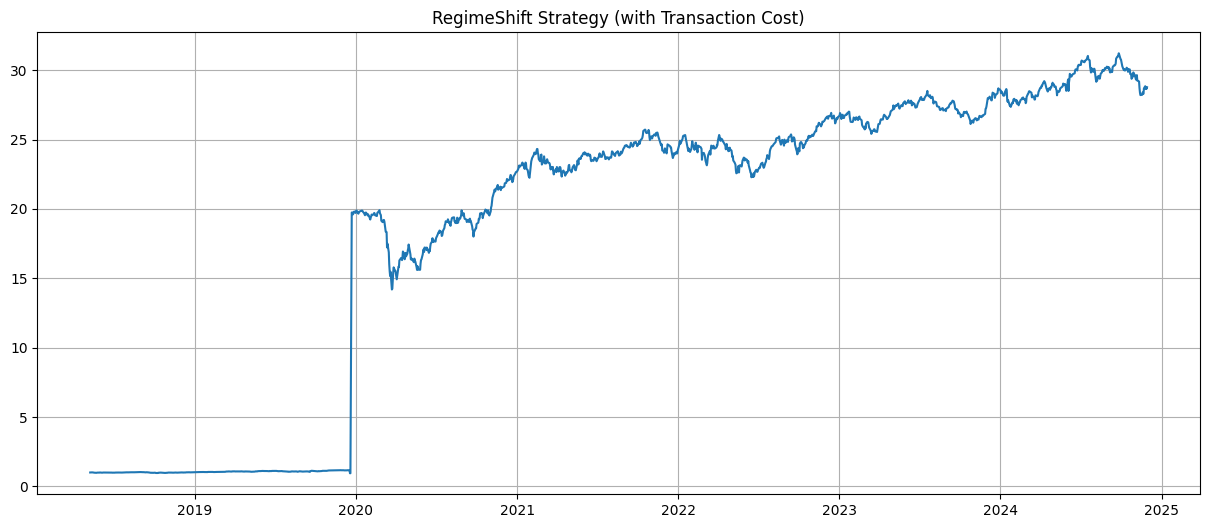

In [36]:
equity = (1 + strategy_returns).cumprod()

plt.figure(figsize=(15,6))

plt.plot(equity)

plt.title("RegimeShift Strategy (with Transaction Cost)")

plt.grid(True)

plt.show()

In [37]:
def sortino_ratio(r):
    downside = r[r < 0]
    return np.sqrt(252) * r.mean() / downside.std()

def calmar_ratio(r):

    equity = (1 + r).cumprod()

    running_max = equity.cummax()

    drawdown = (equity - running_max) / running_max

    max_dd = abs(drawdown.min())

    annual_return = equity.iloc[-1] ** (252 / len(r)) - 1

    return annual_return / max_dd

In [38]:
print("Sharpe Ratio :", sharpe_ratio(strategy_returns))
print("Sortino Ratio :", sortino_ratio(strategy_returns))
print("Calmar Ratio :", calmar_ratio(strategy_returns))
print("Max Drawdown :", max_drawdown(equity))
print("Average Turnover :", turnover.mean())

Sharpe Ratio : 0.4023946509029827
Sortino Ratio : 20.578007130796323
Calmar Ratio : 2.3894270814609664
Max Drawdown : -0.28723715448053094
Average Turnover : 0.15720164609053497


In [39]:
results = pd.DataFrame({
    "Metric": [
        "Sharpe Ratio",
        "Sortino Ratio",
        "Calmar Ratio",
        "Max Drawdown",
        "Average Turnover"
    ],
    "RegimeShift": [
        sharpe_ratio(strategy_returns),
        sortino_ratio(strategy_returns),
        calmar_ratio(strategy_returns),
        max_drawdown(equity),
        turnover.mean()
    ]
})

results

,Metric,RegimeShift
0,Sharpe Ratio,0.402395
1,Sortino Ratio,20.578007
2,Calmar Ratio,2.389427
3,Max Drawdown,-0.287237
4,Average Turnover,0.157202


In [40]:
results = pd.DataFrame({
    "Metric": [
        "Sharpe Ratio",
        "Sortino Ratio",
        "Calmar Ratio",
        "Max Drawdown",
        "Average Turnover"
    ],
    "RegimeShift": [
        sharpe_ratio(strategy_returns),
        sortino_ratio(strategy_returns),
        calmar_ratio(strategy_returns),
        max_drawdown(equity),
        turnover.mean()
    ]
})

results

,Metric,RegimeShift
0,Sharpe Ratio,0.402395
1,Sortino Ratio,20.578007
2,Calmar Ratio,2.389427
3,Max Drawdown,-0.287237
4,Average Turnover,0.157202


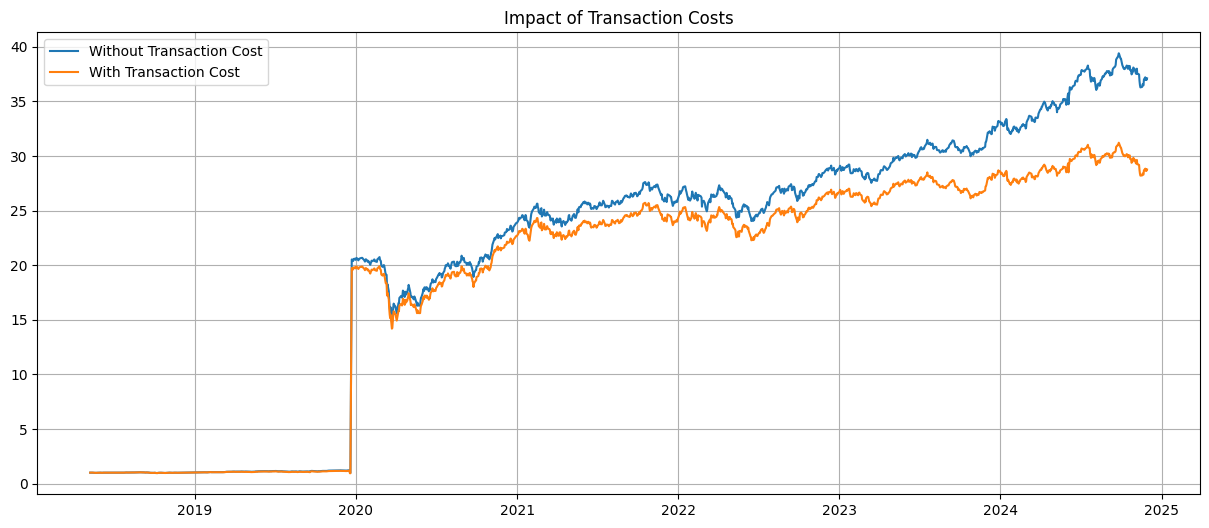

In [41]:
plt.figure(figsize=(15,6))

plt.plot(strategy, label="Without Transaction Cost")
plt.plot(equity, label="With Transaction Cost")

plt.legend()

plt.grid(True)

plt.title("Impact of Transaction Costs")

plt.show()